In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import chi2
from scipy.stats import norm
from scipy.stats import t
from scipy.stats import multivariate_t

In [3]:
tickers=['AAPL','MSFT','PG','JPM','C']
weights=np.array([0.20,0.20,0.20,0.20,0.20])
prices=yf.download(tickers,start='2023-12-15',auto_adjust=False)['Adj Close']

[*********************100%***********************]  5 of 5 completed


In [4]:
prices.tail()

Ticker,AAPL,C,JPM,MSFT,PG
Date,,,,,
2026-08-06,312.140808,133.820007,356.299988,499.859985,146.970001
2026-08-07,313.059998,135.000000,357.519989,499.989990,145.789993
2026-08-10,308.260010,135.220001,359.790009,506.059998,146.440002
2026-08-11,304.910004,135.770004,362.040009,503.809998,145.210007
2026-08-12,303.174988,137.350006,362.779999,496.217010,144.475006


In [5]:
returns=prices.ffill().pct_change().dropna()
returns

Ticker,AAPL,C,JPM,MSFT,PG
Date,,,,,
2023-12-18,-0.008503,-0.003412,0.006052,0.005179,0.015351
2023-12-19,0.005360,0.025574,0.013355,0.001637,0.000000
2023-12-20,-0.010714,-0.016886,-0.011279,-0.007073,-0.015461
2023-12-21,-0.000770,0.010585,0.005704,0.007879,0.002432
2023-12-22,-0.005547,0.005139,-0.000597,0.002784,0.007071
...,...,...,...,...,...
2026-08-06,0.004534,-0.027754,-0.008184,0.025438,0.001158
2026-08-07,0.002945,0.008818,0.003424,0.000260,-0.008029
2026-08-10,-0.015332,0.001630,0.006349,0.012140,0.004459


In [6]:
portfolio_returns=returns.dot(weights).dropna()
portfolio_returns

Date
2023-12-18    0.002934
2023-12-19    0.009185
2023-12-20   -0.012283
2023-12-21    0.005166
2023-12-22    0.001770
                ...   
2026-08-06   -0.000962
2026-08-07    0.001484
2026-08-10    0.001849
2026-08-11   -0.002678
2026-08-12   -0.002428
Length: 664, dtype: float64

In [7]:
var=np.percentile(portfolio_returns,1)
es=portfolio_returns[portfolio_returns<=var].mean()
print("Historical Var:",var)
print("Historical ES:",es)

Historical Var: -0.02568692436151965
Historical ES: -0.03780804545713263


In [8]:
mu=portfolio_returns.mean()
sigma=portfolio_returns.std()
z=norm.ppf(0.01)
phi=norm.pdf(z)
parametric_var_normal=mu+z*sigma
parametric_es_normal=mu-sigma*phi/0.01
print("Parametric Var Normal:",parametric_var_normal)
print("Parametric ES Normal:",parametric_es_normal)

Parametric Var Normal: -0.022975254475206115
Parametric ES Normal: -0.026462162493201387


In [9]:
df=t.fit(portfolio_returns)
print("DF:",df)

DF: (np.float64(3.8700575038014016), np.float64(0.001255999144662504), np.float64(0.006977640242683583))


In [10]:
df,loc,scale=t.fit(portfolio_returns)
alpha=0.01
t_score=t.ppf(alpha,df)
pdf_cutoff=t.pdf(t_score,df)
parametric_var_t=loc+(t_score*scale)
parametric_es_t=loc-(scale*(pdf_cutoff/alpha)*((df+t_score**2)/(df-1)))
print("Parametric Var T:",parametric_var_t)
print("Parametric ES T:",parametric_es_t)

Parametric Var T: -0.025380615270682572
Parametric ES T: -0.03620467329211012


In [11]:
mu=returns.mean()
cov=returns.cov()
simulated=np.random.multivariate_normal(mu,cov,10000)
simulated_returns=simulated.dot(weights)
montecarlo_var_normal=np.percentile(simulated_returns,1)
montecarlo_es_normal=simulated_returns[simulated_returns<=montecarlo_var_normal].mean()
print("MonteCarlo Var Normal:",montecarlo_var_normal)
print("MonteCarlo ES Normal:",montecarlo_es_normal)

MonteCarlo Var Normal: -0.023399869328528843
MonteCarlo ES Normal: -0.026453144452546807


In [12]:
df,loc,scale=t.fit(portfolio_returns)
simulated_returns=t.rvs(df=df,loc=loc,scale=scale,random_state=42,size=10000)
montecarlo_var_t=np.percentile(simulated_returns,1)
montecarlo_es_t=simulated_returns[simulated_returns<=montecarlo_var_t].mean()
print("MonteCarlo Var T:",montecarlo_var_t)
print("MonteCarlo ES T:",montecarlo_es_t)

MonteCarlo Var T: -0.025370173064161013
MonteCarlo ES T: -0.03624451008798264


In [14]:
exceptions=portfolio_returns<var
actual_exceptions=exceptions.sum()
n=len(portfolio_returns)
expected_exceptions=n*0.01
print("Expected Exceptions:",expected_exceptions)
print("Actual Exceptions:",actual_exceptions)

Expected Exceptions: 6.640000000000001
Actual Exceptions: 7


In [15]:
x=actual_exceptions
p=0.01
n=len(portfolio_returns)

LR_uc=-2*(
    (x*np.log(p)+(n-x)*np.log(1-p))-
    (x*np.log(x/n)+(n-x)*np.log(1-x/n))
)
print("LR UC:",LR_uc)

LR UC: 0.019371786182588835


In [16]:
i=(portfolio_returns<var).astype(int)
epsilon=1e-10

n00=((i.shift(1)==0)&(i==0)).sum()
n01=((i.shift(1)==0)&(i==1)).sum()
n10=((i.shift(1)==1)&(i==0)).sum()
n11=((i.shift(1)==1)&(i==1)).sum()

pi0=(n01+epsilon)/(n00+n01+2*epsilon)
pi1=(n11+epsilon)/(n10+n11+2*epsilon)
pi=(n01+n11+2*epsilon)/(n00+n01+n10+n11+4*epsilon)

LR_ind=-2*(
    (n00*np.log(1-pi+epsilon)+n01*np.log(pi+epsilon)+
     n10*np.log(1-pi+epsilon)+n11*np.log(pi+epsilon))-
    (n00*np.log(1-pi0+epsilon)+n01*np.log(pi0+epsilon)+
     n10*np.log(1-pi1+epsilon)+n11*np.log(pi1+epsilon)) 
)
print("LR IND:",LR_ind)

LR IND: 3.618541641676188


In [17]:
LR_cc=LR_uc+LR_ind
print("LR CC:",LR_cc)

LR CC: 3.637913427858777


In [18]:
p_uc = chi2.sf(LR_uc, df=1)
p_ind = chi2.sf(LR_ind, df=1)
p_cc = chi2.sf(LR_cc, df=2)

print("P Value UC:",p_uc)
print("P Value Ind:",p_ind)
print("P Value CC:",p_cc)

P Value UC: 0.889305886130606
P Value Ind: 0.0571389399186377
P Value CC: 0.16219487835170956


In [ ]:
#Rolling 250-day VaR (out-of-sample, no look-ahead)

In [19]:
window = 250

# Historical rolling VaR — 1st percentile of trailing 250-day window, shifted 1 day to avoid look-ahead
rolling_var_hist = portfolio_returns.rolling(window).apply(lambda x: np.percentile(x, 1), raw=True).shift(1)

# Parametric Normal rolling VaR — mean/std of trailing window, shifted 1 day
rolling_mu = portfolio_returns.rolling(window).mean().shift(1)
rolling_sigma = portfolio_returns.rolling(window).std().shift(1)
rolling_var_param = rolling_mu + norm.ppf(0.01) * rolling_sigma

rolling_df = pd.DataFrame({
    'portfolio_returns': portfolio_returns,
    'rolling_var_hist': rolling_var_hist,
    'rolling_var_param': rolling_var_param
}).dropna()

rolling_df.tail()

,portfolio_returns,rolling_var_hist,rolling_var_param
Date,,,
2026-08-06,-0.000962,-0.02116,-0.020796
2026-08-07,0.001484,-0.02116,-0.020803
2026-08-10,0.001849,-0.02116,-0.020771
2026-08-11,-0.002678,-0.02116,-0.020762
2026-08-12,-0.002428,-0.02116,-0.020739


In [ ]:
#Rolling VaR backtest — Historical method

In [20]:
breach_hist = rolling_df['portfolio_returns'] < rolling_df['rolling_var_hist']
n_roll = len(rolling_df)
x_roll = breach_hist.sum()
expected_roll = n_roll * 0.01

print("Rolling window (days):", n_roll)
print("Expected exceptions:", expected_roll)
print("Actual exceptions (Historical):", x_roll)

LR_uc_roll = -2 * (
    (x_roll*np.log(0.01) + (n_roll-x_roll)*np.log(0.99)) -
    (x_roll*np.log(x_roll/n_roll) + (n_roll-x_roll)*np.log(1-x_roll/n_roll))
)
p_uc_roll = chi2.sf(LR_uc_roll, df=1)
print("Rolling Kupiec LR:", LR_uc_roll, "| p-value:", p_uc_roll)

Rolling window (days): 414
Expected exceptions: 4.14
Actual exceptions (Historical): 6
Rolling Kupiec LR: 0.7412179054866215 | p-value: 0.3892710186834608


In [22]:
# Basel Traffic-Light Backtesting

#Basel's market risk framework doesn't stop at a Kupiec p-value — it classifies the exception count over the most recent **250 trading days** into a zone, which determines whether a capital multiplier penalty applies:

#| Zone | Exceptions (out of 250) | Capital multiplier impact |
#|---|---|---|
#| **Green** | 0 – 4 | None — model considered accurate |
#| **Yellow** | 5 – 9 | Increasing scaling factor (1.40 → 1.85), supervisory scrutiny |
#| **Red** | 10+ | Model presumed flawed, forces multiplier to 1.85 minimum, review required |

#This is applied here to the trailing 250-day window of the rolling, out-of-sample VaR series (no look-ahead) —the framework is defined for a fixed 250-day evaluation period, not a variable-length backtest.

In [23]:
def basel_zone(exceptions):
    if exceptions <= 4:
        return 'Green', 'No penalty — model accurate'
    elif exceptions <= 9:
        return 'Yellow', 'Increasing capital multiplier — supervisory scrutiny'
    else:
        return 'Red', 'Model presumed flawed — max multiplier, review required'

# Trailing 250-day window of the rolling backtest series
last_250 = rolling_df.tail(250)
n_last_250 = len(last_250)

exceptions_hist_250 = (last_250['portfolio_returns'] < last_250['rolling_var_hist']).sum()
exceptions_param_250 = (last_250['portfolio_returns'] < last_250['rolling_var_param']).sum()

zone_hist, note_hist = basel_zone(exceptions_hist_250)
zone_param, note_param = basel_zone(exceptions_param_250)

basel_summary = pd.DataFrame({
    'Model': ['Historical VaR (rolling)', 'Parametric Normal VaR (rolling)'],
    'Exceptions (last 250d)': [exceptions_hist_250, exceptions_param_250],
    'Zone': [zone_hist, zone_param],
    'Implication': [note_hist, note_param]
})

basel_summary

,Model,Exceptions (last 250d),Zone,Implication
0,Historical VaR (rolling),1,Green,No penalty — model accurate
1,Parametric Normal VaR (rolling),2,Green,No penalty — model accurate


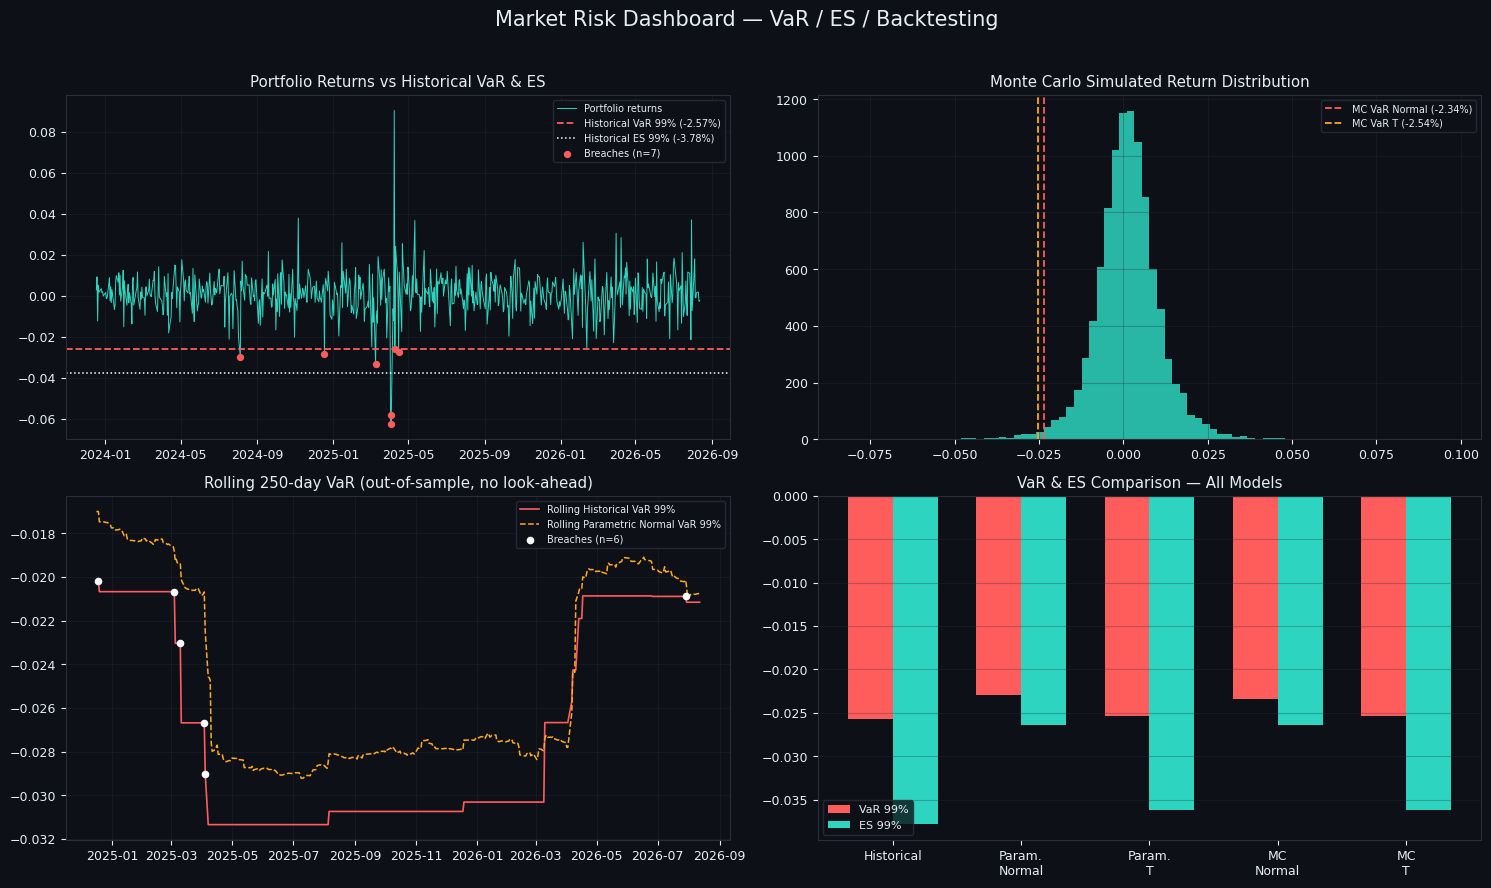

In [28]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- established dark theme ---
BG = '#0d1117'
GRID = '#2a2e37'
TEXT = '#e6edf3'
CORAL = '#ff5c5c'
TEAL = '#2dd4bf'
AMBER = '#ffa726'

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG, 'savefig.facecolor': BG,
    'axes.edgecolor': GRID, 'axes.labelcolor': TEXT, 'text.color': TEXT,
    'xtick.color': TEXT, 'ytick.color': TEXT, 'grid.color': GRID,
    'font.size': 9
})

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle('Market Risk Dashboard — VaR / ES / Backtesting', fontsize=15, color=TEXT, y=0.98)

# Panel 1 — Portfolio returns with Historical VaR/ES + breaches
ax = axes[0, 0]
ax.plot(portfolio_returns.index, portfolio_returns, color=TEAL, linewidth=0.7, label='Portfolio returns')
ax.axhline(var, color=CORAL, linestyle='--', linewidth=1.3, label=f'Historical VaR 99% ({var:.2%})')
ax.axhline(es, color='white', linestyle=':', linewidth=1.1, label=f'Historical ES 99% ({es:.2%})')
breach_mask = portfolio_returns < var
ax.scatter(portfolio_returns.index[breach_mask], portfolio_returns[breach_mask], color=CORAL, s=18, zorder=5, label=f'Breaches (n={breach_mask.sum()})')
ax.set_title('Portfolio Returns vs Historical VaR & ES', color=TEXT)
ax.legend(fontsize=7, facecolor=BG, edgecolor=GRID, labelcolor=TEXT)
ax.grid(alpha=0.3)

# Panel 2 — Monte Carlo simulated return distribution
ax = axes[0, 1]
ax.hist(simulated_returns, bins=80, color=TEAL, alpha=0.85)
ax.axvline(montecarlo_var_normal, color=CORAL, linestyle='--', linewidth=1.3, label=f'MC VaR Normal ({montecarlo_var_normal:.2%})')
ax.axvline(montecarlo_var_t, color=AMBER, linestyle='--', linewidth=1.3, label=f'MC VaR T ({montecarlo_var_t:.2%})')
ax.set_title('Monte Carlo Simulated Return Distribution', color=TEXT)
ax.legend(fontsize=7, facecolor=BG, edgecolor=GRID, labelcolor=TEXT)
ax.grid(alpha=0.3)

# Panel 3 — Rolling 250d VaR (out-of-sample) with breaches
ax = axes[1, 0]
ax.plot(rolling_df.index, rolling_df['rolling_var_hist'], color=CORAL, linewidth=1.2, label='Rolling Historical VaR 99%')
ax.plot(rolling_df.index, rolling_df['rolling_var_param'], color=AMBER, linewidth=1.1, linestyle='--', label='Rolling Parametric Normal VaR 99%')
roll_breach = rolling_df['portfolio_returns'] < rolling_df['rolling_var_hist']
ax.scatter(rolling_df.index[roll_breach], rolling_df['rolling_var_hist'][roll_breach], color='white', s=20, zorder=5, label=f'Breaches (n={roll_breach.sum()})')
ax.set_title('Rolling 250-day VaR (out-of-sample, no look-ahead)', color=TEXT)
ax.legend(fontsize=7, facecolor=BG, edgecolor=GRID, labelcolor=TEXT)
ax.grid(alpha=0.3)

# Panel 4 — VaR & ES comparison across all five models
ax = axes[1, 1]
models = ['Historical', 'Param.\nNormal', 'Param.\nT', 'MC\nNormal', 'MC\nT']
var_vals = [var, parametric_var_normal, parametric_var_t, montecarlo_var_normal, montecarlo_var_t]
es_vals = [es, parametric_es_normal, parametric_es_t, montecarlo_es_normal, montecarlo_es_t]
x = np.arange(len(models))
width = 0.35
ax.bar(x - width/2, var_vals, width, color=CORAL, label='VaR 99%')
ax.bar(x + width/2, es_vals, width, color=TEAL, label='ES 99%')
ax.set_xticks(x)
ax.set_xticklabels(models, color=TEXT)
ax.set_title('VaR & ES Comparison — All Models', color=TEXT)
ax.legend(fontsize=8, facecolor=BG, edgecolor=GRID, labelcolor=TEXT)
ax.grid(alpha=0.3, axis='y')
ax.axhline(0, color=GRID, linewidth=0.8)

for ax_ in axes.flat:
    for spine in ax_.spines.values():
        spine.set_color(GRID)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()